In [1]:
import utils
import networkx as nx
import matplotlib.pyplot as plt
import random

In [ ]:
N = 3000
num_vertex = 6
num_confounding = 1
utils.estimate_good_probability(N, num_vertex, num_confounding)

1.0

In [42]:
for i in range(1,37):
    print(utils.estimate_good_probability(3000, 9, i))

1.0
0.9886666666666667
0.979
0.9606666666666667
0.9643333333333334
0.9386666666666666
0.941
0.941
0.9326666666666666
0.932
0.9236666666666666
0.9293333333333333
0.92
0.9273333333333333
0.9303333333333333
0.933
0.922
0.9343333333333333
0.9343333333333333
0.9273333333333333
0.9383333333333334
0.932
0.9266666666666666
0.931
0.9393333333333334
0.942
0.935
0.9306666666666666
0.9366666666666666
0.9416666666666667
0.9306666666666666
0.9336666666666666
0.94
0.9383333333333334
0.9353333333333333
0.9446666666666667


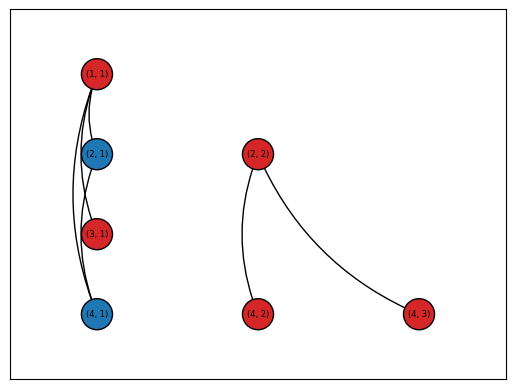

True

In [5]:
n = 4
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)
E1 = [(1,2),(2,3),(3,4)]
B1 = [(2,3),(3,4)]
E2 = [(1,2),(1,4)]
B2 = [(2,3),(3,4)]
G1.add_edges_from(E1)
G2.add_edges_from(E2)
utils.plot_auxiliary(G1,G2,B1,B2)

In [30]:
utils.check_inclusion(G1,G2,B1,B2)

False

In [ ]:
def minimal_vertex_covers_fast(G):
    """
    Enumerate all inclusion-wise minimal vertex covers.

    Parameters
    ----------
    G : nx.Graph

    Returns
    -------
    generator of sets
        Minimal vertex covers
    """

    # maximal independent sets of G
    # = maximal cliques of complement(G)
    H = nx.complement(G)

    V = set(G.nodes())

    for clique in nx.find_cliques(H):
        independent_set = set(clique)

        # complement gives minimal vertex cover
        yield V - independent_set

In [6]:
G = nx.Graph()

G.add_edges_from([
    (1,3),
    (1,4),
    (4,2)
])

for C in minimal_vertex_covers(G):
    print(C)

{3, 4}
{1, 4}
{1, 2}


In [3]:
from utils import * 

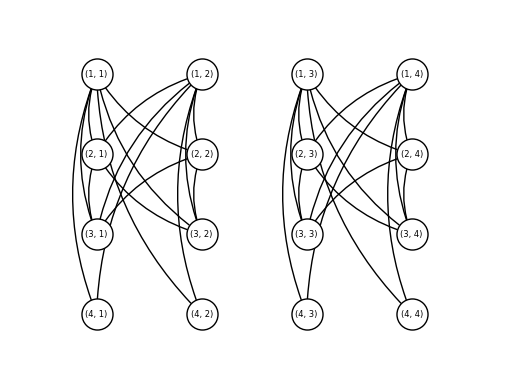

In [159]:
num_vertex = 4
num_confounding = 2

G1 = random_dag(num_vertex,random.random())
B1 = random_confounding(num_vertex,num_confounding)
G2 = random_dag(num_vertex,random.random())
B2 = random_confounding(num_vertex,num_confounding)

V = range(1,num_vertex+1)
IG = induced_graph(V,B1,B2)
plot_induced(IG)

In [162]:
for C in minimal_vertex_covers(IG):
    print(C)

{(4, 4), (2, 4), (2, 1), (3, 4), (4, 3), (3, 1), (4, 2), (2, 3), (3, 3), (2, 2), (3, 2), (4, 1)}
{(4, 4), (2, 4), (1, 2), (2, 1), (3, 4), (4, 3), (1, 1), (2, 3), (3, 3), (2, 2)}
{(4, 4), (2, 4), (1, 2), (3, 4), (4, 3), (3, 1), (1, 1), (2, 3), (3, 3), (3, 2)}
{(1, 3), (2, 1), (3, 4), (3, 1), (1, 4), (4, 2), (3, 3), (2, 2), (3, 2), (4, 1)}
{(1, 2), (2, 1), (3, 4), (1, 1), (1, 4), (3, 3), (2, 2), (1, 3)}
{(1, 2), (3, 4), (3, 1), (1, 1), (1, 4), (3, 3), (3, 2), (1, 3)}
{(1, 3), (2, 4), (2, 1), (3, 1), (1, 4), (4, 2), (2, 3), (2, 2), (3, 2), (4, 1)}
{(2, 4), (1, 2), (2, 1), (1, 1), (1, 4), (2, 3), (2, 2), (1, 3)}
{(2, 4), (1, 2), (3, 1), (1, 1), (1, 4), (2, 3), (3, 2), (1, 3)}


In [163]:
P = powerset(IG.nodes())
covers = inclusive_minimal_covers(IG,P)
for C in covers:
    print(C)

{(2, 4), (1, 2), (2, 1), (1, 1), (1, 4), (2, 3), (2, 2), (1, 3)}
{(2, 4), (1, 2), (3, 1), (1, 1), (1, 4), (2, 3), (3, 2), (1, 3)}
{(1, 2), (2, 1), (3, 4), (1, 1), (1, 4), (3, 3), (2, 2), (1, 3)}
{(1, 2), (3, 4), (3, 1), (1, 1), (1, 4), (3, 3), (3, 2), (1, 3)}
{(2, 4), (2, 1), (4, 1), (3, 1), (1, 4), (4, 2), (2, 3), (2, 2), (3, 2), (1, 3)}
{(2, 1), (3, 4), (4, 1), (3, 1), (1, 4), (4, 2), (3, 3), (2, 2), (3, 2), (1, 3)}
{(4, 4), (2, 4), (1, 2), (2, 1), (3, 4), (4, 3), (1, 1), (2, 3), (3, 3), (2, 2)}
{(4, 4), (2, 4), (1, 2), (3, 4), (4, 3), (3, 1), (1, 1), (2, 3), (3, 3), (3, 2)}
{(4, 4), (2, 4), (2, 1), (3, 4), (4, 3), (3, 1), (4, 2), (2, 3), (3, 3), (2, 2), (3, 2), (4, 1)}
